# The Fourth Circle: Neural Networks, Part Four 
## Transformers III: BERT

<br/>
Jiří Fejlek

2026-05-16
<br/>

Up to this point, all models we have discussed were task-specific; they were designed and trained to perform a specific task, e.g., image classification. Bidirectional Encoder Representations from Transformers (BERT) [[1](#1)] is designed to be *task-agnostic*, requiring minimal architectural changes to solve a wide range of natural language processing (NLP) tasks [[2](#2)].

Namely, BERT primarily provides input sequence representations that can then be used, e.g., for single-text classification (sentiment analysis) and text-pair classification (natural language inference). Unlike pretrained simple word embeddings such as GloVe (https://nlp.stanford.edu/projects/glove/), which represent each token with a context-independent fixed vector, the outputs of BERT are context-sensitive *sentence embeddings*. When we used pretrained word embeddings GloVe (see *Recurrent Neural Networks III: Bidirectional Recurrent Neural Networks*), we still had to build a complex architecture on top of them to perform a given NLP task (in our case, sentiment analysis). We will see that with BERT, we merely need an additional linear classification layer.


## Table of Contents

- [BERT Architecture](#bert_arch)
- [BERT Pretraining](#bert_pretrain)
    - [Masked Language Modeling](#bert_mlm)
    - [Next Sentence Prediction](#bert_nsp)
    - [BERT Pretraining Model](#bert_pre_model)
- [WikiText-2 Dataset](#wikitext)
    - [Tokenizer](#wikitext_tokenize)
    - [Next Sentence Prediction Task](#wikitext_nsp)
    - [Masked Language Modeling Task](#wikitext_mlp)
    - [Dataset Class](#dataset_class)
- [Pretraining BERT](#pretraining)
- [Fine-Tuning BERT](#fine-tuning)
- [Fine-Tuning BERT-base](#bert_base)
- [References](#references)


## BERT Architecture <a class="anchor" id="bert_arch"></a>

From the perspective of neural network architecture, BERT is nothing new to us; it is a transformer, specifically its encoder (see the image below from https://towardsdatascience.com/a-complete-guide-to-bert-with-code-9f87602e4a11/). 

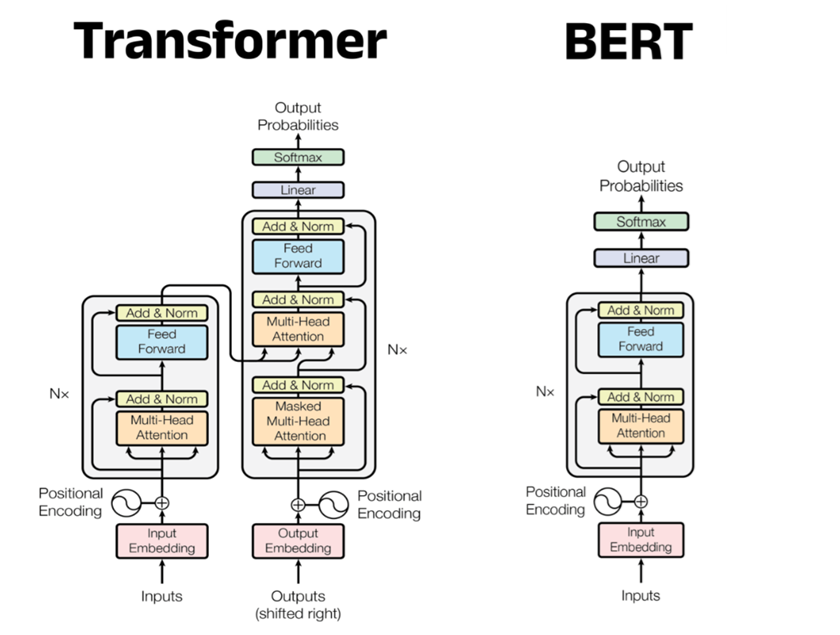

Since we are after sequence representations, it is natural to reduce the architecture to an encoder. Looking at this architecture, it also makes sense why the sequence representations from a pretrained BERT are much more powerful than pretrained word embeddings; in the first case, we have almost the full final architecture pretrained (except the task-specific final layers), in the latter case, we have pretrained only the input embedding. 

Let us implement BERT using the transformer from our last project.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import math
import random

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import re
import collections
import os

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def masked_softmax(X, valid_lens): 
    
    def _sequence_mask(X, valid_len, value = 0):
        maxlen = X.size(1)
        mask = torch.arange((maxlen), dtype = torch.float32, device = X.device)[None, :] < valid_len[:, None]
        X[~mask] = value
        return X
        
    if valid_lens is None:
        return nn.functional.softmax(X, dim = -1)
    else:
        shape = X.shape
        
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)

        X = _sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [4]:
class DotProductAttention(nn.Module):
    
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, queries, keys, values, valid_lens = None):
        
        d = queries.shape[-1]
         
        # Queries: (batch_size, number of queries, q_d)
        # Keys: (batch_size, number of keys = number of values, k_d)
        # Values: (batch_size, number of keys = number of values, v_d)
        # Valid_lens: (batch_size) or (batch_size, number of queries)
        
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)

        return torch.bmm(self.dropout(self.attention_weights), values)

In [5]:
class MultiHeadAttention(nn.Module): 

    def transpose_qkv(self, X):
        
        X = X.reshape(X.shape[0], X.shape[1], self.num_heads, -1)
        X = X.permute(0, 2, 1, 3)
        return X.reshape(-1, X.shape[2], X.shape[3])
        
    def transpose_output(self, X):
        
        X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2])
        X = X.permute(0, 2, 1, 3)
        return X.reshape(X.shape[0], X.shape[1], -1)
        
    def __init__(self, attention_size, num_heads, dropout, bias = False):
        
        super().__init__()
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(attention_size, bias = bias)
        self.W_k = nn.LazyLinear(attention_size, bias = bias)
        self.W_v = nn.LazyLinear(attention_size, bias = bias)
        self.W_o = nn.LazyLinear(attention_size, bias = bias)
        
    def forward(self, queries, keys, values, valid_lens):
        
        queries = self.transpose_qkv(self.W_q(queries))
        keys = self.transpose_qkv(self.W_k(keys))
        values = self.transpose_qkv(self.W_v(values))
        
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, repeats=self.num_heads, dim=0)
            
        output = self.attention(queries, keys, values, valid_lens)
        output_concat = self.transpose_output(output)
            
        return self.W_o(output_concat)

In [6]:
class PositionWiseFFN(nn.Module): 
    
    def __init__(self, ffn_size, ffn_output_size):
        
        super().__init__()
        self.dense1 = nn.LazyLinear(ffn_size)
        self.relu = nn.ReLU()
        self.dense2 = nn.LazyLinear(ffn_output_size)
        
    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

In [7]:
class AddNorm(nn.Module):
    
    def __init__(self, norm_shape, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(norm_shape)
    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

In [8]:
class TransformerEncoderBlock(nn.Module): 
    
    def __init__(self, hidden_size, num_heads, ffn_size, dropout, use_bias = False):
        super().__init__()
        
        self.attention = MultiHeadAttention(hidden_size, num_heads, dropout, use_bias)
        self.addnorm1 = AddNorm(hidden_size, dropout)
        self.ffn = PositionWiseFFN(ffn_size, hidden_size)
        self.addnorm2 = AddNorm(hidden_size, dropout)
        
    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

One slight difference between the transformer encoder and BERT is the *segment embedding*. As we will see in a bit, the BERT is pretrained on inputs that consist of the concatenation of two sequences separated by the special separation token *\<sep\>*. This is done to help BERT understand the relationship between two text sequences. To distinguish these text pairs, BERT adds segment embeddings $e_A$ and $e_B$ to the token embeddings and positional embeddings [[2](#2)]. 

In addition, notice that each input starts with the special classification token *\<cls\>*. This token (or, more correctly, its representation after the transformer block) is used as input to the classification layer during pretraining [[2](#2)]. 

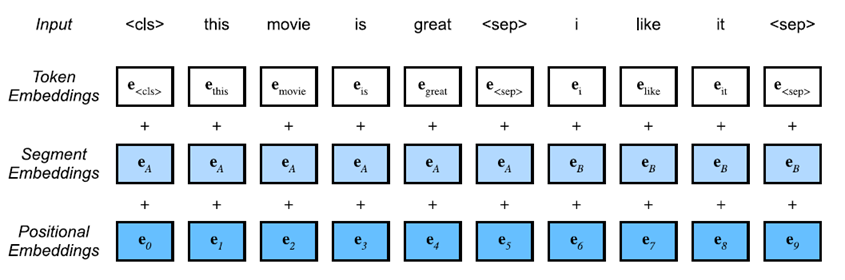

Overall, we get the following BERT encoder [[2](#2)].

In [9]:
class BERTEncoder(nn.Module):

    def __init__(self, vocab_size, hidden_size, ffn_size, num_heads, num_blks, dropout, max_len = 1000):
        super().__init__()
        
        self.token_embedding = nn.Embedding(vocab_size, hidden_size)
        self.segment_embedding = nn.Embedding(2, hidden_size)
        
        # learnable positional embeddings 
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, hidden_size))

        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", TransformerEncoderBlock(hidden_size, num_heads, ffn_size, dropout, use_bias = True))
               
    def forward(self, tokens, segments, valid_lens):
        # Shape of `X` remains unchanged in the following code snippet: # (batch size, max sequence length, `num_hiddens`)
        
        X = self.token_embedding(tokens) + self.segment_embedding(segments)
        X = X + self.pos_embedding[:, :X.shape[1], :]
        for blk in self.blks:
            X = blk(X, valid_lens)
        return X  

We can check the output of the implementation.

In [10]:
vocab_size = 10000 
hidden_size = 256
ffn_size = 4*256 
num_heads = 4

num_blks = 2
dropout = 0.1

encoder = BERTEncoder(vocab_size, hidden_size, num_heads, num_heads, num_blks, dropout)

tokens = torch.randint(0, vocab_size, (2, 8))
segments = torch.tensor([[0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 1, 1, 1, 1, 1]])
encoded_X = encoder(tokens, segments, None)
encoded_X.shape

torch.Size([2, 8, 256])

## BERT Pretraining <a class="anchor" id="bert_pretrain"></a>

As we discussed in the introduction, BERT is typically not initially trained for a specific NLP task. Instead, it is pretrained on a large corpus of unlabeled text data and solves the following artificial tasks.

### Masked Language Modeling <a class="anchor" id="bert_mlm"></a>

To train BERT to produce token representations, the first problem that BERT solves during pretraining is masked language modeling (MLM). In this task, 15% of the tokens in any input sequence are selected at random for prediction. Most of the time, these tokens are masked using the special token *\<mask\>*. However, since the token *\<mask\>* will never appear in the actual NLP tasks (during fine-tuning), sometimes the masked token is replaced with a random token or not replaced at all. This ensures there is not a strong "mismatch" between pretraining and fine-tuning [[1](#1)]. 

Overall, the token replacements are performed as follows [[1](#1)].
* a special *\<mask\>* token for 80% of the time 
* a random token for 10% of the time 
* the unchanged label token for 10% of the time

We will use the MLM implementation from [[2](#2)]. The following *nn.Module* serves as the masked token prediction layer for the BERT encoder.

In [11]:
class MaskLM(nn.Module):

    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.LazyLinear(hidden_size),
            nn.ReLU(),
            nn.LayerNorm(hidden_size),
            nn.LazyLinear(vocab_size)
        )
    def forward(self, X, pred_positions):
        
        num_pred_positions = pred_positions.shape[1]
        pred_positions = pred_positions.reshape(-1)
        batch_size = X.shape[0]

        # Let batch_size = 2, num_pred_positions = 3, then batch_idx is torch.tensor([0, 0, 0, 1, 1, 1])
        batch_idx = torch.arange(0, batch_size)
        batch_idx = torch.repeat_interleave(batch_idx, num_pred_positions)
        
        masked_X = X[batch_idx, pred_positions]
        masked_X = masked_X.reshape((batch_size, num_pred_positions, -1))
        mlm_Y_hat = self.mlp(masked_X)
        return mlm_Y_hat

To see how this module works, let us assume the following encoded input from the BERT encoder.

In [12]:
encoded_X

tensor([[[-0.3197,  1.8018,  0.2454,  ..., -0.3921, -1.9152, -0.1643],
         [ 0.8368, -1.0793, -1.1191,  ..., -0.9809, -0.4343,  1.1833],
         [-0.3182,  0.2005,  0.4722,  ..., -0.3982, -1.2915,  1.2077],
         ...,
         [-0.7081,  0.6800,  0.2782,  ..., -1.4821, -0.9969,  0.0651],
         [-0.3819,  0.3272,  0.7801,  ..., -0.5312,  0.3503,  0.3388],
         [-0.0543,  1.2162,  0.3339,  ..., -0.1701, -0.7157, -0.3337]],

        [[-1.5316,  1.1296,  0.4805,  ..., -0.6415, -1.1159, -0.7996],
         [-0.1662, -0.4224, -1.4698,  ..., -1.0559, -0.8504,  1.5752],
         [ 0.0404,  0.7102,  0.6840,  ...,  0.0064, -1.0123,  1.4392],
         ...,
         [ 0.2908,  0.3405,  0.8565,  ..., -1.2511, -0.5358,  0.4417],
         [-1.4404,  1.0137,  0.3952,  ...,  0.4285, -0.4206, -0.3600],
         [-0.9859,  1.3607,  0.8833,  ...,  0.1709, -0.4659,  0.3316]]],
       grad_fn=<NativeLayerNormBackward0>)

We assume *batch_size* = 2, *hidden_size* = 256, and the sequences have a length of 8.

In [13]:
encoded_X.size()

torch.Size([2, 8, 256])

Let us assume that the following tokens were masked.

In [14]:
mlm_positions = torch.tensor([[1, 5, 2], [6, 1, 5]])

Hence, we extract the decoder's representations corresponding to the masked tokens. We need to perform a bit of reshuffling of indices first.

In [15]:
batch_idx = torch.arange(0, 2)
batch_idx

tensor([0, 1])

In [16]:
batch_idx = torch.repeat_interleave(batch_idx, 3)
batch_idx

tensor([0, 0, 0, 1, 1, 1])

In [17]:
pred_positions = mlm_positions.reshape(-1)
pred_positions

tensor([1, 5, 2, 6, 1, 5])

Finally, we can extract the representations of masked tokens.

In [18]:
masked_X = encoded_X[batch_idx, pred_positions]
masked_X

tensor([[ 0.8368, -1.0793, -1.1191,  ..., -0.9809, -0.4343,  1.1833],
        [-0.7081,  0.6800,  0.2782,  ..., -1.4821, -0.9969,  0.0651],
        [-0.3182,  0.2005,  0.4722,  ..., -0.3982, -1.2915,  1.2077],
        [-1.4404,  1.0137,  0.3952,  ...,  0.4285, -0.4206, -0.3600],
        [-0.1662, -0.4224, -1.4698,  ..., -1.0559, -0.8504,  1.5752],
        [ 0.2908,  0.3405,  0.8565,  ..., -1.2511, -0.5358,  0.4417]],
       grad_fn=<IndexBackward0>)

The multilayer perceptron *mlp* then computes probability logits from these values.  Overall, we get the following output from *MaskLM.*

In [19]:
mlm = MaskLM(vocab_size, hidden_size)
mlm_positions = torch.tensor([[1, 5, 2], [6, 1, 5]])
mlm_Y_hat = mlm(encoded_X, mlm_positions)
mlm_Y_hat.shape

torch.Size([2, 3, 10000])

We can compare the predictions with the actual tokens using the usual cross-entropy loss.

In [20]:
mlm_Y = torch.tensor([[7, 8, 9], [10, 20, 30]])
loss = nn.CrossEntropyLoss(reduction='none')
mlm_l = loss(mlm_Y_hat.reshape((-1, vocab_size)), mlm_Y.reshape(-1))
mlm_l

tensor([ 8.5709,  9.7020, 10.5607,  8.8172,  8.9989,  8.7374],
       grad_fn=<NllLossBackward0>)

In [21]:
mlm_l.size()

torch.Size([6])

### Next Sentence Prediction <a class="anchor" id="bert_nsp"></a>

The second task BERT solves during pretraining is next sentence prediction. Many important downstream tasks, such as natural language inference, rely on understanding the relationships between sentences. To pretrain BERT for these tasks, the model's input consists of two text sequences separated by the token *\<sep\>*.  For half of the time, these text sequences are consecutive in the original data; the other half, the second sequence is randomly selected from the dataset. The task is to discern between these two scenarios [[1](#1)].

We can solve the next-sentence prediction task using a simple linear binary classifier (BERT uses the *\<cls\>* representation as an input for the *NextSentencePred* layer) [[2](#2)].

In [22]:
class NextSentencePred(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.output = nn.LazyLinear(2)
        
    def forward(self, X):
        # X: (batch size, hidden_size)
        return self.output(X)

### BERT Pretraining Model <a class="anchor" id="bert_pre_model"></a>

We can now put all the pieces together and obtain the following BERT model, ready for pretraining [[2](#2)].

In [27]:
class BERTModel(nn.Module):
    
    def __init__(self, vocab_size, hidden_size, ffn_size, num_heads, num_blks, dropout, max_len=1000):
        
        super().__init__()
        self.encoder = BERTEncoder(vocab_size, hidden_size, ffn_size, num_heads, num_blks, dropout, max_len=max_len)
        self.hidden = nn.Sequential(nn.LazyLinear(hidden_size), nn.Tanh())
        self.mlm = MaskLM(vocab_size, hidden_size)
        self.nsp = NextSentencePred()

    def forward(self, tokens, segments, valid_lens=None, pred_positions=None):
    
        encoded_X = self.encoder(tokens, segments, valid_lens)
    
        if pred_positions is not None:
            mlm_Y_hat = self.mlm(encoded_X, pred_positions)
        else:
            mlm_Y_hat = None
        
        nsp_Y_hat = self.nsp(self.hidden(encoded_X[:, 0, :]))
        return encoded_X, mlm_Y_hat, nsp_Y_hat

## WikiText-2 Dataset <a class="anchor" id="wikitext"></a>

We have the BERT model ready, but we also need a suitable dataset. The original BERT model [[1](#1)] was trained on BooksCorpus (800M words) [[3](#3)] and English Wikipedia (2,500M words). Of course, in our demonstration, we use a significantly smaller dataset, namely, WikiText-2 [[4](#4)]. 

First, let us read the dataset. The text is split into paragraphs. We will use only those with multiple sentences (so we can perform next sentence prediction) [[2](#2)].

In [28]:
def _read_wiki(data_dir):
    file_name = os.path.join(data_dir, 'wiki.train.tokens')
    with open(file_name, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    # Uppercase letters are converted to lowercase ones
    paragraphs = [line.strip().lower().split(' . ')
                  for line in lines if len(line.split(' . ')) >= 2]
    random.shuffle(paragraphs)
    return paragraphs

In [29]:
random.seed(123)
wikitext = _read_wiki('D:/nine circles 2/wikitext-2')

In [30]:
len(wikitext)

15496

In [31]:
wikitext[0]

["in 1821 etty 's the <unk> of cleopatra in cilicia ( also known as the triumph of cleopatra ) was a critical success",
 'the painting featured nude figures , and over the following years etty painted further nudes in biblical , literary and mythological settings',
 'all but one of the 15 paintings etty exhibited in the 1820s included at least one nude figure .']

### Tokenizer <a class="anchor" id="wikitext_tokenize"></a>

The next step in our data preparation is tokenization. We will use words as our tokens and our older code to build a vocabulary.

In [32]:
def tokenize(lines, token='word'): 
    # Split text lines into word or character tokens
    assert token in ('word', 'char'), 'Unknown token type: ' + token
    return [line.split() if token == 'word' else list(line) for line in lines]

In [33]:
class Vocabulary: 

    def __init__(self, tokens = [], min_freq = 0, reserved_tokens = []):
        
        # Flatten the list of tokens
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse = True)

        # The list of unique tokens, we ignore tokens with frequency lower than min_freq
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [token for token, freq in self.token_freqs if freq >= min_freq]))) 
        # Convert tokens to indices
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
     
    def __len__(self):
        return len(self.idx_to_token)
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk) # return unknown token if not in the vocabulary
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]
    
    @property
    def unk(self): # index for the unknown token
        return self.token_to_idx['<unk>']

In [34]:
paragraphs = [tokenize(paragraph, token='word') for paragraph in wikitext] 
sentences = [sentence for paragraph in paragraphs for sentence in paragraph]

For example, the first paragraph is tokenized as follows.

In [35]:
paragraphs[0]

[['in',
  '1821',
  'etty',
  "'s",
  'the',
  '<unk>',
  'of',
  'cleopatra',
  'in',
  'cilicia',
  '(',
  'also',
  'known',
  'as',
  'the',
  'triumph',
  'of',
  'cleopatra',
  ')',
  'was',
  'a',
  'critical',
  'success'],
 ['the',
  'painting',
  'featured',
  'nude',
  'figures',
  ',',
  'and',
  'over',
  'the',
  'following',
  'years',
  'etty',
  'painted',
  'further',
  'nudes',
  'in',
  'biblical',
  ',',
  'literary',
  'and',
  'mythological',
  'settings'],
 ['all',
  'but',
  'one',
  'of',
  'the',
  '15',
  'paintings',
  'etty',
  'exhibited',
  'in',
  'the',
  '1820s',
  'included',
  'at',
  'least',
  'one',
  'nude',
  'figure',
  '.']]

In [36]:
sentences[0]

['in',
 '1821',
 'etty',
 "'s",
 'the',
 '<unk>',
 'of',
 'cleopatra',
 'in',
 'cilicia',
 '(',
 'also',
 'known',
 'as',
 'the',
 'triumph',
 'of',
 'cleopatra',
 ')',
 'was',
 'a',
 'critical',
 'success']

In [37]:
sentences[1]

['the',
 'painting',
 'featured',
 'nude',
 'figures',
 ',',
 'and',
 'over',
 'the',
 'following',
 'years',
 'etty',
 'painted',
 'further',
 'nudes',
 'in',
 'biblical',
 ',',
 'literary',
 'and',
 'mythological',
 'settings']

We need to remember to add 4 special tokens to the vocabulary.

In [38]:
vocab = Vocabulary(sentences, min_freq=5, reserved_tokens = ['<pad>', '<mask>', '<cls>', '<sep>'])

In [39]:
vocab[sentences[0]]

[9515,
 350,
 6923,
 38,
 18282,
 946,
 12999,
 4074,
 9515,
 3961,
 45,
 1506,
 10581,
 1977,
 18282,
 18785,
 12999,
 4074,
 46,
 19647,
 956,
 5048,
 17715]

### Next Sentence Prediction Task  <a class="anchor" id="wikitext_nsp"></a>

Having tokenized the text, we continue preprocessing by preparing sentence pairs. We will use the implementation from [[2](#2)], which is as follows.

In [40]:
def _get_next_sentence(sentence, next_sentence, paragraphs):
    if random.random() < 0.5:
        is_next = True
    else:
        # `paragraphs` is a list of lists of lists
        next_sentence = random.choice(random.choice(paragraphs))
        is_next = False    
    return sentence, next_sentence, is_next

In [41]:
def _get_nsp_data_from_paragraph(paragraph, paragraphs, vocab, max_len):
    nsp_data_from_paragraph = []
    
    for i in range(len(paragraph) - 1):
        tokens_a, tokens_b, is_next = _get_next_sentence(paragraph[i], paragraph[i + 1], paragraphs)
        
        # 1x '<cls>' token and 2x '<sep>' tokens
        if len(tokens_a) + len(tokens_b) + 3 > max_len:
            continue
        tokens, segments = get_tokens_and_segments(tokens_a, tokens_b)
        nsp_data_from_paragraph.append((tokens, segments, is_next))
    return nsp_data_from_paragraph

In [42]:
def get_tokens_and_segments(tokens_a, tokens_b=None):
    tokens = ['<cls>'] + tokens_a + ['<sep>']
    # 0 and 1 are marking segment A and B, respectively
    segments = [0] * (len(tokens_a) + 2)
    if tokens_b is not None:
        tokens += tokens_b + ['<sep>']
        segments += [1] * (len(tokens_b) + 1)
    return tokens, segments

Let us check how the code works. Let us assume the first paragraph.

In [43]:
wikitext[0]

["in 1821 etty 's the <unk> of cleopatra in cilicia ( also known as the triumph of cleopatra ) was a critical success",
 'the painting featured nude figures , and over the following years etty painted further nudes in biblical , literary and mythological settings',
 'all but one of the 15 paintings etty exhibited in the 1820s included at least one nude figure .']

We will select the first sentence (cropped to the maximum token length *max_len* of the model) and combine it with the next sentence from the paragraph. With probability 0.5, we will combine it with a randomly selected sentence instead.

In [44]:
max_len = 64
sep_paragraph = _get_nsp_data_from_paragraph(paragraphs[0], paragraphs, vocab, max_len)

Variable *sep_paragraph* consists of both tokenized sequences and a 0/1 mask, which differentiates between segments. 

In [45]:
 ' '.join(sep_paragraph[0][0]) 

"<cls> in 1821 etty 's the <unk> of cleopatra in cilicia ( also known as the triumph of cleopatra ) was a critical success <sep> in the sitcom <unk> , the character lennie <unk> is a villa supporter <sep>"

In [46]:
torch.LongTensor(sep_paragraph[0][1])

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [47]:
sep_paragraph[0][0][:sum(torch.LongTensor(sep_paragraph[0][1])==0)]

['<cls>',
 'in',
 '1821',
 'etty',
 "'s",
 'the',
 '<unk>',
 'of',
 'cleopatra',
 'in',
 'cilicia',
 '(',
 'also',
 'known',
 'as',
 'the',
 'triumph',
 'of',
 'cleopatra',
 ')',
 'was',
 'a',
 'critical',
 'success',
 '<sep>']

In [48]:
sep_paragraph[0][0][sum(torch.LongTensor(sep_paragraph[0][1])==0)+1:]

['the',
 'sitcom',
 '<unk>',
 ',',
 'the',
 'character',
 'lennie',
 '<unk>',
 'is',
 'a',
 'villa',
 'supporter',
 '<sep>']

We notice that the second sentence is not related to the first; it was selected at random. Hence, the classification label for this pair is "False".

In [49]:
sep_paragraph[0][2]

False

Let us process the whole dataset.

In [50]:
examples = []
for paragraph in paragraphs:
    examples.extend(_get_nsp_data_from_paragraph(paragraph, paragraphs, vocab, max_len))

In [51]:
examples[0]

(['<cls>',
  'in',
  '1821',
  'etty',
  "'s",
  'the',
  '<unk>',
  'of',
  'cleopatra',
  'in',
  'cilicia',
  '(',
  'also',
  'known',
  'as',
  'the',
  'triumph',
  'of',
  'cleopatra',
  ')',
  'was',
  'a',
  'critical',
  'success',
  '<sep>',
  'from',
  'the',
  'military',
  'perspective',
  ',',
  'it',
  'removed',
  'the',
  'burden',
  'of',
  'dealing',
  'with',
  'thousands',
  'of',
  'uncooperative',
  'draftees',
  'and',
  'segregated',
  'the',
  'cos',
  'and',
  'their',
  'philosophy',
  'from',
  'military',
  'service',
  'members',
  '.',
  '<sep>'],
 [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1],
 False)

### Masked Language Modeling Task <a class="anchor" id="wikitext_mlp"></a>

Masked language modeling is performed at the same time as the next sentence prediction. Hence, 15% of the tokens in the sentence pairs are masked, as discussed earlier. Let us check the implementation from [[2](#2)].

In [52]:
def _replace_mlm_tokens(tokens, candidate_pred_positions, num_mlm_preds, vocab):
    
    # For the input of a masked language model, make a new copy of tokens and replace some of them with '<mask>' or random tokens
    mlm_input_tokens = [token for token in tokens]
    pred_positions_and_labels = []
    
    # Get 15% random tokens for the prediction task
    random.shuffle(candidate_pred_positions)
    for mlm_pred_position in candidate_pred_positions:
        
        if len(pred_positions_and_labels) >= num_mlm_preds:
            break
        masked_token = None
        
        # 80% of the time: replace the word with the '<mask>' token, 10% of the time: keep the word unchanged, 10% of the time: replace the word with a random word
        if random.random() < 0.8:
            masked_token = '<mask>'
        else:
            if random.random() < 0.5:
                masked_token = tokens[mlm_pred_position]
            else:
                masked_token = random.choice(vocab.idx_to_token)
        
        mlm_input_tokens[mlm_pred_position] = masked_token
        pred_positions_and_labels.append((mlm_pred_position, tokens[mlm_pred_position]))
        
    return mlm_input_tokens, pred_positions_and_labels

In [53]:
def _get_mlm_data_from_tokens(tokens, vocab):
    
    candidate_pred_positions = []
    for i, token in enumerate(tokens):
        # Special tokens are not predicted in the masked language modeling task
        if token in ['<cls>', '<sep>']:
            continue
        candidate_pred_positions.append(i)

    # 15% of random tokens are predicted in the masked language modeling task
    num_mlm_preds = max(1, round(len(tokens) * 0.15))
    mlm_input_tokens, pred_positions_and_labels = _replace_mlm_tokens(tokens, candidate_pred_positions, num_mlm_preds, vocab)
    pred_positions_and_labels = sorted(pred_positions_and_labels, key = lambda x: x[0])
    
    pred_positions = [v[0] for v in pred_positions_and_labels]
    mlm_pred_labels = [v[1] for v in pred_positions_and_labels]
    return vocab[mlm_input_tokens], pred_positions, vocab[mlm_pred_labels]

In [54]:
examples = [(_get_mlm_data_from_tokens(tokens, vocab) + (segments, is_next)) for tokens, segments, is_next in examples]

The result for the first sentence pair is as follows.

In [55]:
vocab.to_tokens(examples[0][0])

['<cls>',
 '560',
 '1821',
 'etty',
 '<mask>',
 'the',
 '<unk>',
 'of',
 'cleopatra',
 'in',
 'cilicia',
 '(',
 'also',
 'known',
 'as',
 'the',
 'triumph',
 'of',
 'cleopatra',
 ')',
 'was',
 'a',
 'critical',
 'success',
 '<sep>',
 'from',
 '<mask>',
 'military',
 '<mask>',
 ',',
 'it',
 'removed',
 'the',
 'burden',
 'of',
 '<mask>',
 'with',
 'thousands',
 'of',
 '<unk>',
 'draftees',
 'and',
 '<mask>',
 'the',
 'cos',
 'and',
 'their',
 'philosophy',
 'from',
 'military',
 'service',
 'octagonal',
 '.',
 '<sep>']

These are the tokens that were replaced. Notice that the token '1821' stayed the same, and 'in' and 'members' were replaced by random tokens. The rest were masked by *\<mask\>*.

In [56]:
idx = examples[0][1]
[vocab.to_tokens(examples[0][0])[x] for x in idx]

['560', '1821', '<mask>', '<mask>', '<mask>', '<mask>', '<mask>', 'octagonal']

In [57]:
vocab.to_tokens(examples[0][2])

['in', '1821', "'s", 'the', 'perspective', 'dealing', 'segregated', 'members']

### Dataset Class <a class="anchor" id="dataset_class"></a>

The last piece of the puzzle we require is a function that pads sentence pairs to the same length to allow batching. The following function [[2](#2)] does that. It also creates a mask to distinguish padded tokens to ignore their loss in the MLM prediction task.   

In [60]:
def _pad_bert_inputs(examples, max_len, vocab):
    
    max_num_mlm_preds = round(max_len * 0.15)
    all_token_ids, all_segments, valid_lens, = [], [], []
    all_pred_positions, all_mlm_weights, all_mlm_labels = [], [], []
    nsp_labels = []
    
    for (token_ids, pred_positions, mlm_pred_label_ids, segments, is_next) in examples:
        all_token_ids.append(torch.tensor(token_ids + [vocab['<pad>']] * (max_len - len(token_ids)), dtype=torch.long))
        all_segments.append(torch.tensor(segments + [0] * (max_len - len(segments)), dtype=torch.long))
    
        # `valid_lens` excludes count of '<pad>' tokens
        valid_lens.append(torch.tensor(len(token_ids), dtype=torch.float32))
        all_pred_positions.append(torch.tensor(pred_positions + [0] * (max_num_mlm_preds - len(pred_positions)), dtype=torch.long))
    
        # Predictions of padded tokens will be filtered out in the loss via multiplication of 0 weights
        all_mlm_weights.append(torch.tensor([1.0] * len(mlm_pred_label_ids) + [0.0] * (max_num_mlm_preds - len(pred_positions)), dtype=torch.float32))
        all_mlm_labels.append(torch.tensor(mlm_pred_label_ids + [0] * (max_num_mlm_preds - len(mlm_pred_label_ids)), dtype=torch.long))
        nsp_labels.append(torch.tensor(is_next, dtype=torch.long))
    
    return (all_token_ids, all_segments, valid_lens, all_pred_positions, all_mlm_weights, all_mlm_labels, nsp_labels)

Overall, we get the following dataset class.

In [61]:
class _WikiTextDataset(torch.utils.data.Dataset):
    
    def __init__(self, paragraphs, max_len):
        
        paragraphs = [tokenize(paragraph, token='word') for paragraph in paragraphs] 
        sentences = [sentence for paragraph in paragraphs for sentence in paragraph]
        
        self.vocab = Vocabulary(sentences, min_freq=5, reserved_tokens = ['<pad>', '<mask>', '<cls>', '<sep>'])
        
        # Get data for the next sentence prediction task
        examples = []
        for paragraph in paragraphs:
            examples.extend(_get_nsp_data_from_paragraph(paragraph, paragraphs, self.vocab, max_len))

        # Get data for the masked language model task
        examples = [(_get_mlm_data_from_tokens(tokens, self.vocab) + (segments, is_next)) for tokens, segments, is_next in examples]
        
        # Pad inputs
        (self.all_token_ids, self.all_segments, self.valid_lens,
         self.all_pred_positions, self.all_mlm_weights,
         self.all_mlm_labels, self.nsp_labels) = _pad_bert_inputs(
             examples, max_len, self.vocab)     

    def __getitem__(self, idx):
        return (self.all_token_ids[idx], self.all_segments[idx],
                self.valid_lens[idx], self.all_pred_positions[idx],
                self.all_mlm_weights[idx], self.all_mlm_labels[idx],
                self.nsp_labels[idx])
            
    def __len__(self):
        return len(self.all_token_ids)

In [62]:
class WikiText(torch.utils.data.Dataset):
    
    
    def _read(self, data_dir):
        file_name = os.path.join(data_dir, 'wiki.train.tokens')
        
        with open(file_name, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        # Uppercase letters are converted to lowercase ones
        paragraphs = [line.strip().lower().split(' . ')
                      for line in lines if len(line.split(' . ')) >= 2]
        
        random.shuffle(paragraphs)
        return paragraphs

    def __init__(self, data_dir, batch_size, max_len):
        
        paragraphs = self._read(data_dir)
        train_set = _WikiTextDataset(paragraphs, max_len)
        train_iter = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)

        self.vocab = train_set.vocab
        self.train_iter = train_iter

Let us check the elements of the finalized dataset. The first item is the tokenized pair of sentences. The second item is a mask that separates sentence pairs and padding. The third element is the sequence length without padding. The fourth element consists of the indices of masked tokens. The fifth element is a mask that separates masked \<pad\> tokens from the rest. The sixth element is the tensor of the original tokens, and the last element is the classification label for the next sentence prediction. 

In [63]:
paragraphs = _read_wiki('D:/nine circles 2/wikitext-2')
train_set = _WikiTextDataset(paragraphs, max_len)

In [64]:
train_set.__getitem__(1)

(tensor([  942, 18282,  7568,  5103, 18795,    49,  4295,  3292, 10916, 19382,
         12999,  2196,    49,   943,  2090,   943,  9515,  6374,   943,   138,
           945,  1631,  9408, 12999,  9286,  1622,  9052,  1929,  7722, 18279,
         12208,    49,  1622,   943,  9340, 12999,  5202,  1622,  2865, 10093,
         12999,  1727, 17072,   943, 18282,  5104,   945,   944,   944,   944,
           944,   944,   944,   944,   944,   944,   944,   944,   944,   944,
           944,   944,   944,   944]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor(47.),
 tensor([13, 15, 18, 33, 37, 42, 43,  0,  0,  0]),
 tensor([1., 1., 1., 1., 1., 1., 1., 0., 0., 0.]),
 tensor([10715,  1111, 16475,  9253,  1622, 17072, 10251,     0,     0,     0]),
 tensor(1))

In [65]:
len(train_set)

43656

In [66]:
batch_size = 250
train_iter = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True)

for (tokens_X, segments_X, valid_lens_x, pred_positions_X, mlm_weights_X, mlm_Y, nsp_y) in train_iter:
    print(tokens_X.shape, segments_X.shape, valid_lens_x.shape, pred_positions_X.shape, mlm_weights_X.shape, mlm_Y.shape, nsp_y.shape)
    break

torch.Size([250, 64]) torch.Size([250, 64]) torch.Size([250]) torch.Size([250, 10]) torch.Size([250, 10]) torch.Size([250, 10]) torch.Size([250])


## Pretraining BERT <a class="anchor" id="pretraining"></a>

We are now ready to pretrain BERT. The pretraining loss is a combination of the MLM cross-entropy loss and the NSP cross-entropy loss [[2](#2)].

In [67]:
def _get_batch_loss_bert(bert, loss, vocab_size, tokens_X, segments_X, valid_lens_x,pred_positions_X, mlm_weights_X, mlm_Y, nsp_y):
    
    # Forward pass
    _, mlm_Y_hat, nsp_Y_hat = bert(tokens_X, segments_X, valid_lens_x.reshape(-1), pred_positions_X)
    
    # Compute masked language model loss
    mlm_l = (loss(mlm_Y_hat.reshape(-1, vocab_size), mlm_Y.reshape(-1))*mlm_weights_X.reshape(-1))
    mlm_l = mlm_l.sum() / (mlm_weights_X.sum() + 1e-8)
    
    # Compute next sentence prediction loss
    nsp_l = loss(nsp_Y_hat, nsp_y).mean()
    l = mlm_l + nsp_l
    
    return mlm_l, nsp_l, l

In [68]:
def train_BERT_loop_cuda(train_data_loader, model, loss_fn, optimizer, scheduler, vocab_size, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    mlm_loss_sum_train  = 0
    nsp_loss_sum_train  = 0
    size_train = 0

    
    for batch, (tokens_X, segments_X, valid_lens_x, pred_positions_X, mlm_weights_X, mlm_Y, nsp_y) in enumerate(train_data_loader):

        
        tokens_X = tokens_X.to(cuda_device)
        segments_X = segments_X.to(cuda_device)
        valid_lens_x = valid_lens_x.to(cuda_device)
        pred_positions_X = pred_positions_X.to(cuda_device)
        mlm_weights_X = mlm_weights_X.to(cuda_device)
        mlm_Y = mlm_Y.to(cuda_device)
        nsp_y = nsp_y.to(cuda_device)
        
        optimizer.zero_grad() # zero out the gradients
        
        mlm_l, nsp_l, loss = _get_batch_loss_bert(model, loss_fn, vocab_size, tokens_X, segments_X, valid_lens_x, pred_positions_X, mlm_weights_X, mlm_Y, nsp_y)

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        
        # compute prediction epoch loss
        with torch.no_grad(): # we do not need to compute the gradients
            mlm_loss_sum_train = mlm_loss_sum_train + mlm_l*len(tokens_X)
            nsp_loss_sum_train = nsp_loss_sum_train + nsp_l*len(tokens_X)
            size_train = size_train + len(tokens_X)

    with torch.no_grad(): 
        mlm_loss_sum_train = mlm_loss_sum_train/size_train
        nsp_loss_sum_train = nsp_loss_sum_train/size_train
        
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  mlm_loss_sum_train.detach(), nsp_loss_sum_train.detach(), learning_rate[0]

For illustration purposes, we will consider a relatively small BERT model. The original BERT-Base model [[1](#1)] consists of 12 transformer blocks with *hidden_size* = 768 and, crucially, a context length *max_len* = 512 (remember that the computational complexity of attention is quadratic in *max_len*!).

In [69]:
hidden_size = 256
ffn_size = 4*256
num_heads = 4
num_blks = 2
dropout = 0.1

bert_model = BERTModel(len(vocab), hidden_size = hidden_size, ffn_size = ffn_size, num_heads = num_heads, num_blks = num_blks, dropout = dropout)

batch_size = 250
max_len = 128
max_norm = 100

WikiText_dataset = WikiText('D:/nine circles 2/wikitext-2', batch_size, max_len)
train_iter = WikiText_dataset.train_iter
vocab = WikiText_dataset.vocab

cross_entropy_loss = nn.CrossEntropyLoss(reduction = 'none')

In [70]:
for (tokens_X, segments_X, valid_lens_x, pred_positions_X, mlm_weights_X, mlm_Y, nsp_y) in train_iter:
    break
  
_get_batch_loss_bert(bert_model, cross_entropy_loss, len(vocab), tokens_X, segments_X, valid_lens_x, pred_positions_X, mlm_weights_X, mlm_Y, nsp_y)

(tensor(10.1265, grad_fn=<DivBackward0>),
 tensor(0.7361, grad_fn=<MeanBackward0>),
 tensor(10.8625, grad_fn=<AddBackward0>))

Our BERT model has about 12 million parameters (about 10 times smaller than BERT Base) [[1](#1)].

In [71]:
sum(p.numel() for p in bert_model.parameters() if p.requires_grad)

12359970

We note that for training, we will use the Adam optimizer [[2](#2), [5](#5)], which is commonly used for transformer training. 

In [75]:
bert_model = bert_model.to(cuda_device)

n_epochs = 200
vocab_size = len(vocab)
optim_SGD_cuda = torch.optim.Adam(bert_model.parameters(), lr=0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[150], gamma = 0.1)

mlm_loss_epochs = np.zeros(n_epochs) 
nsp_loss_epochs = np.zeros(n_epochs) 
learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    mlm_loss_epochs[t], nsp_loss_epochs[t], learning_rates[t]  = train_BERT_loop_cuda(train_iter, bert_model, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, vocab_size, max_norm) 
end = time.time()
print(end - start)

2541.7549817562103


MLM and NSP losses are as follows.

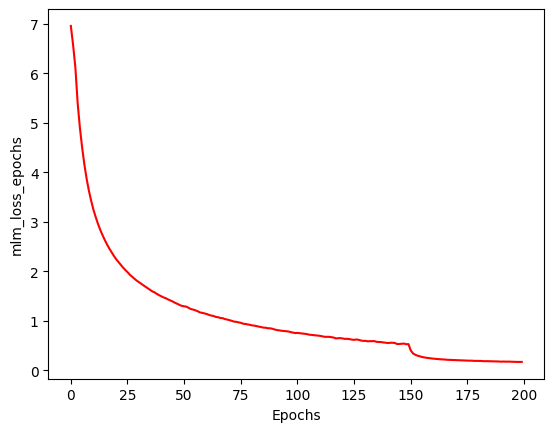

In [76]:
plt.plot(mlm_loss_epochs, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('mlm_loss_epochs');

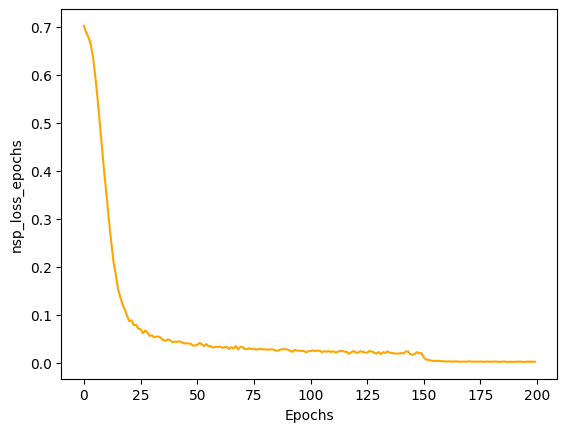

In [77]:
plt.plot(nsp_loss_epochs, color = 'orange')
plt.xlabel('Epochs')
plt.ylabel('nsp_loss_epochs');

In [78]:
mlm_loss_epochs.min()

0.17286765575408936

In [79]:
nsp_loss_epochs.min()

0.0013333414681255817

We observe that our model learned the pretraining dataset well. Let us save the parameters.

In [80]:
torch.save(bert_model.state_dict(), 'D:/nine circles 2/bert')

In [81]:
bert_model.eval()

tokens_X = tokens_X.to(cuda_device)
segments_X = segments_X.to(cuda_device)
valid_lens_x = valid_lens_x.to(cuda_device)
pred_positions_X = pred_positions_X.to(cuda_device)

_, mlm_Y_hat, nsp_Y_hat = bert_model(tokens_X, segments_X, valid_lens_x.reshape(-1), pred_positions_X)

In [82]:
mlm_Y_hat[0]

tensor([[-17.7962,   9.5220, -29.1403,  ..., -10.5034, -15.7812, -31.6974],
        [  3.8542,   5.8505, -15.6948,  ..., -12.4957,  -8.8160,  -5.1363],
        [  0.1653,  10.7775, -11.3272,  ..., -12.1438, -20.3006, -21.3554],
        ...,
        [  6.8447,   6.1569, -16.0404,  ..., -14.7799, -21.8071, -23.3763],
        [  6.8447,   6.1569, -16.0404,  ..., -14.7799, -21.8071, -23.3763],
        [  6.8447,   6.1569, -16.0404,  ..., -14.7799, -21.8071, -23.3763]],
       device='cuda:0', grad_fn=<SelectBackward0>)

We can load the model as follows.

In [83]:
hidden_size = 256
ffn_size = 4*256
num_heads = 4
num_blks = 2
dropout = 0.1

bert_model = BERTModel(len(vocab), hidden_size = hidden_size, ffn_size = ffn_size, num_heads = num_heads, num_blks = num_blks, dropout = dropout).to(cuda_device)
bert_model.load_state_dict(torch.load('D:/nine circles 2/bert', weights_only=True))

<All keys matched successfully>

In [85]:
bert_model.eval()
_, mlm_Y_hat, nsp_Y_hat = bert_model(tokens_X, segments_X, valid_lens_x.reshape(-1), pred_positions_X)

In [86]:
mlm_Y_hat[0]

tensor([[-17.7962,   9.5220, -29.1403,  ..., -10.5034, -15.7812, -31.6974],
        [  3.8542,   5.8505, -15.6948,  ..., -12.4957,  -8.8160,  -5.1363],
        [  0.1653,  10.7775, -11.3272,  ..., -12.1438, -20.3006, -21.3554],
        ...,
        [  6.8447,   6.1569, -16.0404,  ..., -14.7799, -21.8071, -23.3763],
        [  6.8447,   6.1569, -16.0404,  ..., -14.7799, -21.8071, -23.3763],
        [  6.8447,   6.1569, -16.0404,  ..., -14.7799, -21.8071, -23.3763]],
       device='cuda:0', grad_fn=<SelectBackward0>)

We observe that the outputs are indeed the same.

## Fine-Tuning BERT <a class="anchor" id="fine-tuning"></a>

Let us now test our pretrained BERT model and fine-tune it on a specific NLP task. We will consider the IMDb dataset (https://ai.stanford.edu/~amaas/data/sentiment/) [[6](#6)], which consists of 50,000 (25,000 in the training set, 25,000 in the test set) polarized movie reviews (i.e.,  either clearly positive or clearly negative). We used this dataset already in *Recurrent Neural Networks III: Bidirectional Recurrent Neural Networks*.

In [87]:
class IMDb:
    
    def _read(self, is_train):

        data_dir = self.data_dir
                
        reviews, labels = [], []
        for label in ('pos', 'neg'):
            folder_name = os.path.join(data_dir, 'train' if is_train else 'test', label)
            for file in os.listdir(folder_name):
                with open(os.path.join(folder_name, file), 'rb') as f:
                    review = (f.read().decode('utf-8').replace('\n', ''))
                    review = re.sub('([.,!?()])', r' \1 ', review)
                    review = re.sub('\s{2,}', ' ', review)
                    review = re.sub('[^A-Za-z.,!?]+', ' ',review).lower()
                    reviews.append(review)
                    labels.append(1 if label == 'pos' else 0)
        return reviews, labels

    def _tokenize(self, text): # convert text to a list of words
        return [line.split() for line in text]


    def truncate_pad(self, line, padding_token, sep_token):
        num_steps = self.max_len-1
        if len(line) > num_steps:
            return line[:num_steps] + [sep_token] # Truncate
        return line + [sep_token] + [padding_token] * (num_steps - len(line)) # Pad

    def _build(self, is_train, vocab = None): # built vocabulary

        data_dir = self.data_dir
        reviews, labels = self._read(is_train)
        tokens = self._tokenize(reviews)
        
        if vocab is None: 
            vocab = Vocabulary(tokens, min_freq = 5, reserved_tokens= ['<pad>'])

        valid_lens = [min(len(token)+2,self.max_len)  for token in tokens]
        corpus = [vocab[['<cls>']  + token] for token in tokens]
        corpus = [self.truncate_pad(line, vocab['<pad>'], vocab['<sep>']) for line in corpus]
        
        
        return corpus, labels, vocab, valid_lens

    def __init__(self, data_dir, batch_size, max_len, vocab = None):  
        
        self.data_dir = data_dir
        self.max_len = max_len

        
        if vocab is None: 
            train_corpus, train_labels, self.vocab, valid_lens_train = self._build(is_train = True) 
        else:
            self.vocab = vocab
            train_corpus, train_labels, _, valid_lens_train = self._build(is_train = True, vocab = self.vocab)    
            
        test_corpus, test_labels, _, valid_lens_test = self._build(is_train = False, vocab = self.vocab)

        dataset_train = torch.utils.data.TensorDataset(*[torch.tensor(train_corpus), torch.tensor(train_labels), torch.tensor(valid_lens_train)])
        dataset_test = torch.utils.data.TensorDataset(*[torch.tensor(test_corpus), torch.tensor(test_labels), torch.tensor(valid_lens_test)])

        self.train_dataloader = torch.utils.data.DataLoader(dataset_train, batch_size, shuffle = True)
        self.test_dataloader = torch.utils.data.DataLoader(dataset_test, batch_size, shuffle = False)  

We need to tokenize the dataset using the same vocabulary, which we used to pretrain BERT. 

In [88]:
IMDb_dataset = IMDb(data_dir = 'D:/nine circles 2/aclImdb', batch_size = 250, max_len = 128, vocab = vocab)

In [89]:
for X, Y, X_len in IMDb_dataset.train_dataloader:
    print('X:', X, '\nY:', Y, '\nX_len:', X_len)
    break

X: tensor([[  942,  5841,    49,  ...,   944,   944,   944],
        [  942, 11549,   946,  ...,    51, 18282,   945],
        [  942,  5754, 18008,  ...,  8245, 18282,   945],
        ...,
        [  942, 18352,  4894,  ..., 19401,  1875,   945],
        [  942, 10340, 13955,  ..., 15043,  8364,   945],
        [  942,   946,    49,  ..., 12684, 17541,   945]]) 
Y: tensor([0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
        1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
        0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
        1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
        0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
        0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1,
        1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 

In [90]:
len(IMDb_dataset.vocab.to_tokens(X[0]))

128

In [91]:
IMDb_dataset.vocab.to_tokens(X[1])[:X_len[1]]

['<cls>',
 'marie',
 '<unk>',
 'carries',
 'this',
 'depression',
 'era',
 'drama',
 'about',
 'a',
 '<unk>',
 'bank',
 'owner',
 ',',
 'which',
 'recently',
 'aired',
 'on',
 '<unk>',
 'during',
 'their',
 'april',
 '<unk>',
 'comedy',
 'month',
 '.',
 'if',
 'you',
 'come',
 'with',
 'the',
 'expectation',
 'of',
 'big',
 'laughs',
 'courtesy',
 'the',
 '<unk>',
 '<unk>',
 '<unk>',
 'team',
 ',',
 'you',
 '<unk>',
 'be',
 'disappointed',
 ',',
 'as',
 'this',
 'is',
 'really',
 'a',
 'very',
 '<unk>',
 'film',
 '.',
 'it',
 's',
 'also',
 'very',
 'poorly',
 'made',
 ',',
 'surprisingly',
 'so',
 'considering',
 'it',
 'came',
 'from',
 '<unk>',
 '.',
 'leonard',
 'smith',
 's',
 'bare',
 'bones',
 'cinematography',
 'is',
 'strictly',
 'from',
 'the',
 'set',
 'up',
 'the',
 'camera',
 'and',
 'don',
 't',
 'move',
 'it',
 'school',
 ',',
 'frequently',
 'to',
 'the',
 '<unk>',
 'of',
 'the',
 'cast',
 ',',
 'who',
 'find',
 'themselves',
 'delivering',
 'lines',
 'off',
 'screen',


Next, we define a BERT classifier based on our pretrained BERT model. We simply add a dropout layer and a linear layer on top of the BERT decoder's output.

In [92]:
class BERTClassifier(nn.Module):
    
    def __init__(self, bert, dropout = 0):
        super().__init__()
        self.encoder = bert.encoder
        self.hidden = bert.hidden
        self.output = nn.Sequential(nn.Dropout(dropout), nn.LazyLinear(2))
    
    def forward(self, inputs):
        tokens_X, segments_X, valid_lens_x = inputs
        encoded_X = self.encoder(tokens_X, segments_X, valid_lens_x)
        return self.output(self.hidden(encoded_X[:, 0, :]))

In [93]:
bert_class = BERTClassifier(bert_model, dropout = 0.1).to(cuda_device)

In [94]:
bert_class([X.to(cuda_device), torch.zeros(X.size(), dtype=torch.long).to(cuda_device), X_len.to(cuda_device)]).size()

torch.Size([250, 2])

We want to exploit our pretraining a bit. Our classifier model has the following number of parameters.

In [95]:
sum(p.numel() for p in bert_class.parameters() if p.requires_grad)

7087874

In [96]:
bert_class

BERTClassifier(
  (encoder): BERTEncoder(
    (token_embedding): Embedding(20256, 256)
    (segment_embedding): Embedding(2, 256)
    (blks): Sequential(
      (0): TransformerEncoderBlock(
        (attention): MultiHeadAttention(
          (attention): DotProductAttention(
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (W_q): Linear(in_features=256, out_features=256, bias=True)
          (W_k): Linear(in_features=256, out_features=256, bias=True)
          (W_v): Linear(in_features=256, out_features=256, bias=True)
          (W_o): Linear(in_features=256, out_features=256, bias=True)
        )
        (addnorm1): AddNorm(
          (dropout): Dropout(p=0.1, inplace=False)
          (ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        )
        (ffn): PositionWiseFFN(
          (dense1): Linear(in_features=256, out_features=1024, bias=True)
          (relu): ReLU()
          (dense2): Linear(in_features=1024, out_features=256, bias=True)
     

We can reduce the number of trainable parameters significantly by freezing some layers. Namely, we will freeze embedding layers.

In [97]:
for param in bert_class.encoder.token_embedding.parameters():
    param.requires_grad = False

In [98]:
for param in bert_class.encoder.segment_embedding.parameters():
    param.requires_grad = False

In [99]:
sum(p.numel() for p in bert_class.parameters() if p.requires_grad)

1901826

Otherwise, we will allow fine-tuning remaining parameter values (including the transformer blocks). To avoid completely ruining the pretraining, we will use a very small learning rate (e.g., 1e-5 [[1](#1)]).

In [100]:
def train_test_class_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, Y, X_len) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        Y = Y.to(cuda_device)
        X_len = X_len.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model([X,torch.zeros(X.size(), dtype=torch.long).to(cuda_device),X_len]) # forward pass
        loss = loss_fn(pred_logits, Y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-Y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, Y_test, X_len_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            Y_test = Y_test.to(cuda_device)
            X_len_test = X_len_test.to(cuda_device)
            
            pred_logits_test = model([X_test,torch.zeros(X_test.size(), dtype=torch.long).to(cuda_device),X_len_test])
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, Y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-Y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

In [102]:
torch.manual_seed(123)

n_epochs = 100
max_norm = 100
batch_size = 250
max_len = 128

IMDb_dataset = IMDb(data_dir = 'D:/nine circles 2/aclImdb', batch_size = batch_size, max_len = max_len, vocab = vocab)
IMDb_train_loader = IMDb_dataset.train_dataloader
IMDb_test_loader = IMDb_dataset.test_dataloader

cross_entropy_loss = nn.CrossEntropyLoss()

optim_SGD_cuda = torch.optim.Adam(bert_class.parameters(), lr = 0.00001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100], gamma = 0.1)

In [103]:
loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_class_loop_cuda(IMDb_train_loader, IMDb_test_loader, bert_class, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

508.14532256126404


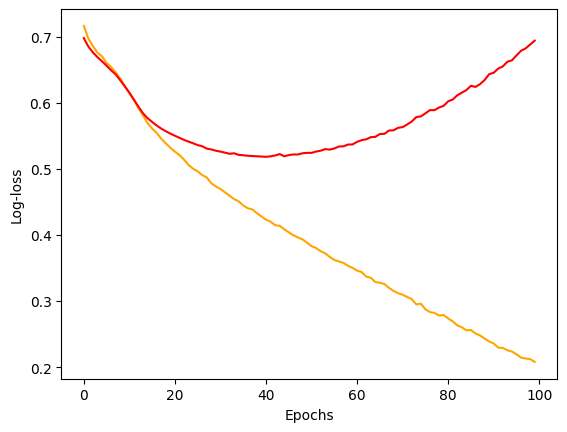

In [104]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

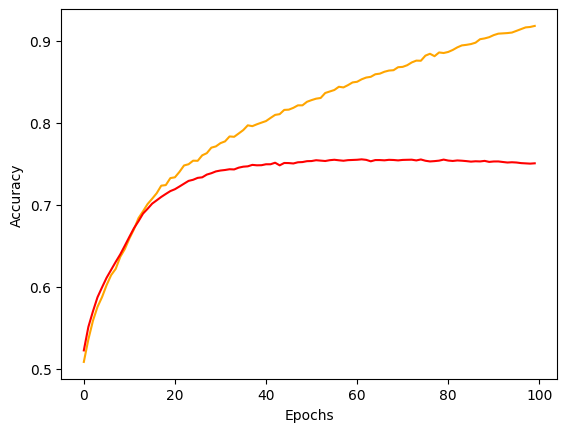

In [105]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [108]:
accu_epochs_train[99]

0.9178799986839294

In [109]:
accu_epochs_test[99]

0.7503199577331543

In [110]:
accu_epochs_test.max()

0.7551599740982056

We achieved 75% accuracy on the test, which isn't that great. The result is about 10% lower than the one we have obtained from a bidirectional GRU model. For comparison, let us train the BERT model from scratch. 

In [112]:
torch.manual_seed(123)

hidden_size = 256
ffn_size = 4*256
num_heads = 4
num_blks = 2
dropout = 0.1

bert_model = BERTModel(len(vocab), hidden_size = hidden_size, ffn_size = ffn_size, num_heads = num_heads, num_blks = num_blks, dropout = dropout)
bert_class = BERTClassifier(bert_model).to(cuda_device)

n_epochs = 100
max_norm = 100
batch_size = 250
max_len = 128

IMDb_dataset = IMDb(data_dir = 'D:/nine circles 2/aclImdb', batch_size = batch_size, max_len = max_len, vocab = vocab)
IMDb_train_loader = IMDb_dataset.train_dataloader
IMDb_test_loader = IMDb_dataset.test_dataloader

bert_class = bert_class.to(cuda_device)
cross_entropy_loss = nn.CrossEntropyLoss()

optim_SGD_cuda = torch.optim.Adam(bert_class.parameters(), lr = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100], gamma = 0.1)

In [113]:
loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_class_loop_cuda(IMDb_train_loader, IMDb_test_loader, bert_class, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

520.8820168972015


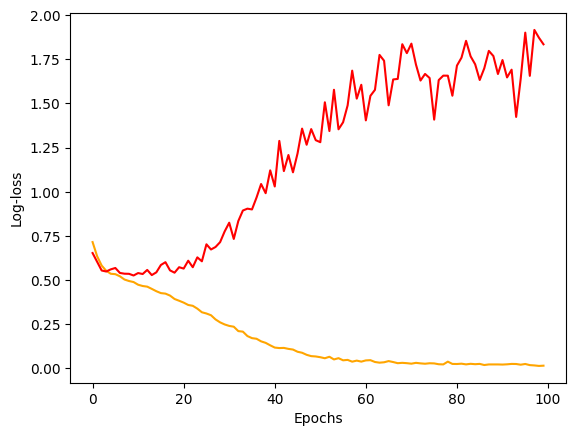

In [114]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

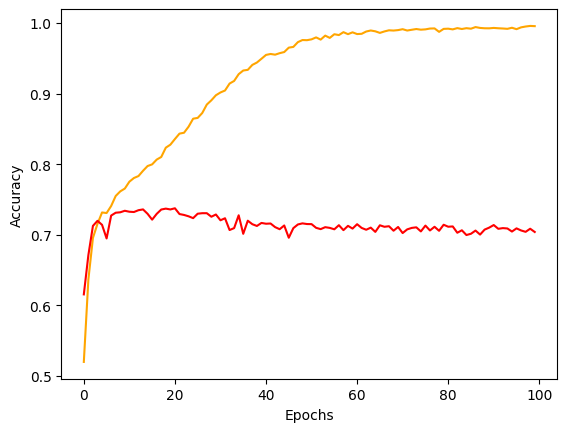

In [115]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [116]:
accu_epochs_train[99]

0.9954399466514587

In [117]:
accu_epochs_test[99]

0.7039200067520142

In [118]:
accu_epochs_test.max()

0.7374799847602844

We achieved very similar accuracy. The results show that to fully exploit the transformer architecture, we need significantly larger pretraining datasets (and longer context lengths than merely 128). Hence, as the last step of this project, let us use the pretrained BERT-base model.

## Fine-Tuning BERT-base <a class="anchor" id="bert_base"></a>

First, we will download the BERT-base model from https://huggingface.co/docs/transformers/model_doc/bert using *transformers* library.

In [119]:
from transformers import BertTokenizer, BertForSequenceClassification

In [120]:
bert_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels = 2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


We can check the architecture. One slight difference between our model and the BERT-base is the usage of the GELU activation function ($\text{GELU}(x) = x \Phi(x)$, where $\Phi$ is the cumulative distribution function of the normal distribution). The GELU activation is very similar to ReLU in shape; however, it is smooth everywhere and does not exactly zero out for small negative values, making it more suitable for gradient-based optimization and less likely to cause neurons to "die."

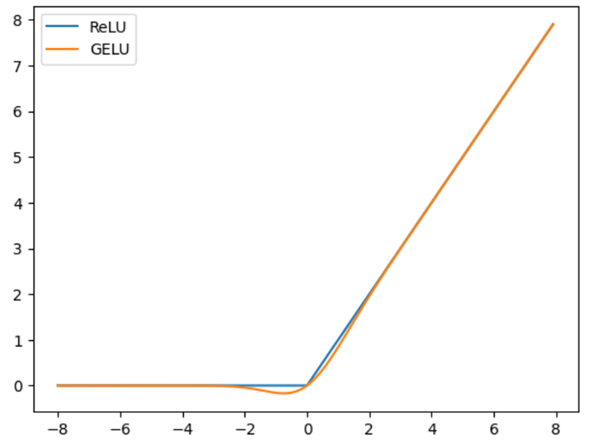

Moreover, we can notice an additional layer normalization layer right after the embeddings, before the transformer blocks.

In [121]:
bert_model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

We also need to download the appropriate tokenizer.

In [122]:
BERT_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

Fortunately, the tokenizer is quite simple to use.

In [123]:
tokenized = BERT_tokenizer(['Hello! How are you?'], return_tensors="pt", padding = True) # pt = pytorch.tensor
tokenized

{'input_ids': tensor([[ 101, 7592,  999, 2129, 2024, 2017, 1029,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

We observe that it produces three outputs: the tokenized sequence, the segment mask, and the attention mask (to denote padding). We can separate the outputs as follows.

In [124]:
tokenized.input_ids

tensor([[ 101, 7592,  999, 2129, 2024, 2017, 1029,  102]])

In [125]:
tokenized.token_type_ids

tensor([[0, 0, 0, 0, 0, 0, 0, 0]])

In [126]:
tokenized.attention_mask

tensor([[1, 1, 1, 1, 1, 1, 1, 1]])

We can also check how the special tokens are denoted. We observe that the tokenizer correctly adds \<CLS\> and \<SEP\> tokens to the sequence.

In [127]:
BERT_tokenizer.convert_tokens_to_ids(['[CLS]'])

[101]

In [128]:
BERT_tokenizer.convert_tokens_to_ids(['[SEP]'])

[102]

In [129]:
BERT_tokenizer.convert_tokens_to_ids(['[PAD]'])

[0]

We can enumerate the BERT-base model as follows.

In [130]:
bert_model(**tokenized)

SequenceClassifierOutput(loss=None, logits=tensor([[0.5163, 0.7972]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [131]:
bert_model(input_ids = tokenized.input_ids, token_type_ids = tokenized.token_type_ids,  attention_mask = tokenized.attention_mask)

SequenceClassifierOutput(loss=None, logits=tensor([[0.5163, 0.7972]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

Lastly, we need to check how to batch the input. We observe that the input should be *batch_size* x *max_length*.

In [132]:
tokenized = BERT_tokenizer(['Hello! How are you?', 'I am fine.'], return_tensors="pt", padding = True) # pt = pytorch.tensor

In [133]:
tokenized.input_ids.size()

torch.Size([2, 8])

Let us tokenize the IMDb dataset.

In [134]:
data_dir = 'D:/nine circles 2/aclImdb'
is_train = True
reviews, labels = [], []
for label in ('pos', 'neg'):
    folder_name = os.path.join(data_dir, 'train' if is_train else 'test', label)
    for file in os.listdir(folder_name):
        with open(os.path.join(folder_name, file), 'rb') as f:
            review = (f.read().decode('utf-8'))
            reviews.append(review)

In [135]:
BERT_tokenizer(reviews[0], return_tensors="pt")

{'input_ids': tensor([[  101, 22953,  2213,  4381,  2152,  2003,  1037,  9476,  4038,  1012,
          2009,  2743,  2012,  1996,  2168,  2051,  2004,  2070,  2060,  3454,
          2055,  2082,  2166,  1010,  2107,  2004,  1000,  5089,  1000,  1012,
          2026,  3486,  2086,  1999,  1996,  4252,  9518,  2599,  2033,  2000,
          2903,  2008, 22953,  2213,  4381,  2152,  1005,  1055, 18312,  2003,
          2172,  3553,  2000,  4507,  2084,  2003,  1000,  5089,  1000,  1012,
          1996, 25740,  2000,  5788, 13732,  1010,  1996, 12369,  3993,  2493,
          2040,  2064,  2156,  2157,  2083,  2037, 17203,  5089,  1005, 13433,
          8737,  1010,  1996,  9004, 10196,  4757,  1997,  1996,  2878,  3663,
          1010,  2035, 10825,  2033,  1997,  1996,  2816,  1045,  2354,  1998,
          2037,  2493,  1012,  2043,  1045,  2387,  1996,  2792,  1999,  2029,
          1037,  3076,  8385,  2699,  2000,  6402,  2091,  1996,  2082,  1010,
          1045,  3202,  7383,  1012,  

We can pad the sequence to BERT's *max_length* as follows.

In [136]:
BERT_tokenizer(reviews[0], return_tensors="pt", padding = 'max_length')

{'input_ids': tensor([[  101, 22953,  2213,  4381,  2152,  2003,  1037,  9476,  4038,  1012,
          2009,  2743,  2012,  1996,  2168,  2051,  2004,  2070,  2060,  3454,
          2055,  2082,  2166,  1010,  2107,  2004,  1000,  5089,  1000,  1012,
          2026,  3486,  2086,  1999,  1996,  4252,  9518,  2599,  2033,  2000,
          2903,  2008, 22953,  2213,  4381,  2152,  1005,  1055, 18312,  2003,
          2172,  3553,  2000,  4507,  2084,  2003,  1000,  5089,  1000,  1012,
          1996, 25740,  2000,  5788, 13732,  1010,  1996, 12369,  3993,  2493,
          2040,  2064,  2156,  2157,  2083,  2037, 17203,  5089,  1005, 13433,
          8737,  1010,  1996,  9004, 10196,  4757,  1997,  1996,  2878,  3663,
          1010,  2035, 10825,  2033,  1997,  1996,  2816,  1045,  2354,  1998,
          2037,  2493,  1012,  2043,  1045,  2387,  1996,  2792,  1999,  2029,
          1037,  3076,  8385,  2699,  2000,  6402,  2091,  1996,  2082,  1010,
          1045,  3202,  7383,  1012,  

However, we also have to ensure that the sequences are truncated to *max_length* as well.

In [137]:
len_review = [len(review) for review in reviews]

In [138]:
np.argmax(len_review)

1954

In [139]:
BERT_tokenizer(reviews[1954], return_tensors="pt")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (3127 > 512). Running this sequence through the model will result in indexing errors


{'input_ids': tensor([[ 101, 2674, 1015,  ..., 1013, 1028,  102]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]])}

In [140]:
BERT_tokenizer(reviews[1954], return_tensors="pt", padding = 'max_length', truncation = True)

{'input_ids': tensor([[  101,  2674,  1015,  1024,  6415,  2136,  2795,  2674, 19606,  4097,
          1998,  9997, 12648,  5443,  5752, 16938,  1998,  3782, 21721, 19606,
          4097,  1998,  9997, 12648,  2318,  2477,  2125,  2007,  1037,  6415,
          2136,  2795,  2674,  2114,  5752, 16938,  1998,  3782, 21721,  1012,
          2429,  2000,  1996,  3513,  1997,  1996,  2674,  1010,  2119,  7892,
          2031,  2000,  2175,  2083,  7251,  1999,  2344,  2000,  2131,  1996,
          2663,  1012, 21721,  1998, 16938,  9685,  2039,  2220,  2006,  2011,
          2635,  4332, 27883,  2034,  9997,  1998,  2059, 19606,  4097,  1012,
          1037,  2446, 10514, 19386,  2011, 21721,  2000, 19606,  2165,  1996,
          3612,  2041,  1997,  1996, 12648,  2567,  1012,  9997,  2699,  2000,
          2393,  2010,  2567,  1010,  2021,  1996,  5330, 19868,  2032,  2096,
         21721,  1998, 16938,  6080,  2098,  2039,  2006,  2032,  1999,  1996,
          3420,  1012,  2007, 21721,  

Overall, we get the following *IMDb* dataset class.

In [141]:
class IMDb2:
    
    def _read_tokenize(self, is_train):

        data_dir = self.data_dir
                
        input_ids, token_type_ids, attention_masks, labels = [], [], [], []
        for label in ('pos', 'neg'):
            folder_name = os.path.join(data_dir, 'train' if is_train else 'test', label)
            for file in os.listdir(folder_name):
                with open(os.path.join(folder_name, file), 'rb') as f:
                    review = (f.read().decode('utf-8').replace('\n', ''))
                    tokenized_review = BERT_tokenizer(review, return_tensors="pt", padding = 'max_length', truncation = True)
                    input_ids.append(tokenized_review.input_ids)
                    token_type_ids.append(tokenized_review.token_type_ids)
                    attention_masks.append(tokenized_review.attention_mask)
                    labels.append(1 if label == 'pos' else 0)
        return input_ids, token_type_ids, attention_masks, labels

    def __init__(self, data_dir, batch_size):  
        
        self.data_dir = data_dir


        train_input_ids, train_token_type_ids, train_attention_masks, train_labels = self._read_tokenize(is_train = True) 
        test_input_ids, test_token_type_ids, test_attention_masks, test_labels = self._read_tokenize(is_train = False)
        

        dataset_train = torch.utils.data.TensorDataset(*[torch.stack(train_input_ids), torch.stack(train_token_type_ids), torch.stack(train_attention_masks), torch.tensor(train_labels)])
        dataset_test = torch.utils.data.TensorDataset(*[torch.stack(test_input_ids), torch.stack(test_token_type_ids), torch.stack(test_attention_masks), torch.tensor(test_labels)])

        self.train_dataloader = torch.utils.data.DataLoader(dataset_train, batch_size, shuffle = True)
        self.test_dataloader = torch.utils.data.DataLoader(dataset_test, batch_size, shuffle = False) 

In [143]:
IMDb_dataset = IMDb2(data_dir = 'D:/nine circles 2/aclImdb', batch_size = 16)

In [144]:
for input_ids, token_type_ids, attention_masks, Y in IMDb_dataset.train_dataloader:
    break
    
input_ids

tensor([[[  101,  1000,  2066,  ...,  1997,  5688,   102]],

        [[  101,  2023,  2003,  ...,     0,     0,     0]],

        [[  101,  1045,  2253,  ...,     0,     0,     0]],

        ...,

        [[  101,  1045,  5621,  ...,     0,     0,     0]],

        [[  101,  9997,  3389,  ...,     0,     0,     0]],

        [[  101,  5321, 24354,  ...,     0,     0,     0]]])

In [145]:
token_type_ids

tensor([[[0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0]]])

In [146]:
attention_masks

tensor([[[1, 1, 1,  ..., 1, 1, 1]],

        [[1, 1, 1,  ..., 0, 0, 0]],

        [[1, 1, 1,  ..., 0, 0, 0]],

        ...,

        [[1, 1, 1,  ..., 0, 0, 0]],

        [[1, 1, 1,  ..., 0, 0, 0]],

        [[1, 1, 1,  ..., 0, 0, 0]]])

In [147]:
Y

tensor([1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0])

Let us fine-tune the BERT-base model. Let us ensure the batch enumeration works well.

In [148]:
bert_model(input_ids = input_ids.flatten(1), token_type_ids = token_type_ids.flatten(1),  attention_mask = attention_masks.flatten(1))

SequenceClassifierOutput(loss=None, logits=tensor([[0.2129, 0.4906],
        [0.5176, 0.6860],
        [0.3674, 0.6407],
        [0.4200, 0.7390],
        [0.4578, 0.8261],
        [0.2572, 0.4524],
        [0.3969, 0.6489],
        [0.4129, 0.6037],
        [0.3621, 0.6594],
        [0.4337, 0.7899],
        [0.3244, 0.6632],
        [0.4507, 0.7748],
        [0.3321, 0.5847],
        [0.4509, 0.7017],
        [0.3787, 0.5690],
        [0.4177, 0.6773]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

The number of trainable parameters of BERT-base is as follows.

In [149]:
sum(p.numel() for p in bert_model.parameters() if p.requires_grad)

109483778

We will again freeze the embedding layers to make training a bit easier.

In [150]:
bert_model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [151]:
bert_model.bert.embeddings

BertEmbeddings(
  (word_embeddings): Embedding(30522, 768, padding_idx=0)
  (position_embeddings): Embedding(512, 768)
  (token_type_embeddings): Embedding(2, 768)
  (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [152]:
for param in bert_model.bert.embeddings.parameters():
    param.requires_grad = False

In [153]:
sum(p.numel() for p in bert_model.parameters() if p.requires_grad)

85646594

In [154]:
def train_test_class_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (input_ids, token_type_ids, attention_masks, Y) in enumerate(train_data_loader):

        input_ids = input_ids.flatten(1).to(cuda_device)
        token_type_ids = token_type_ids.flatten(1).to(cuda_device)
        attention_masks = attention_masks.flatten(1).to(cuda_device)
        Y = Y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        output = model(input_ids = input_ids, token_type_ids = token_type_ids, attention_mask = attention_masks) # forward pass
        pred_logits = output.logits
        loss = loss_fn(pred_logits, Y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        
        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(input_ids)
            size_train = size_train + len(input_ids)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-Y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (input_ids_test, token_type_ids_test, attention_masks_test, Y_test) in enumerate(test_data_loader):

            input_ids_test = input_ids_test.flatten(1).to(cuda_device)
            token_type_ids_test = token_type_ids_test.flatten(1).to(cuda_device)
            attention_masks_test = attention_masks_test.flatten(1).to(cuda_device)
            Y_test = Y_test.to(cuda_device)
            
            output = model(input_ids = input_ids_test, token_type_ids = token_type_ids_test, attention_mask = attention_masks_test)
            pred_logits_test = output.logits
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, Y_test)*len(input_ids_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-Y_test).abs() == 0).long().sum()
            size_test = size_test + len(input_ids_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

The BERT-base model is very large, so we need to use a small batch size; 16 was about adequate for the 12GB of VRAM we have available. Correspondingly, we also set a very low number of training epochs.

In [156]:
torch.manual_seed(123)

batch_size = 16
n_epochs = 5
max_norm = 100

IMDb_dataset = IMDb2(data_dir = 'D:/nine circles 2/aclImdb', batch_size = batch_size)
IMDb_train_loader = IMDb_dataset.train_dataloader
IMDb_test_loader = IMDb_dataset.test_dataloader

bert_model = bert_model.to(cuda_device)
cross_entropy_loss = nn.CrossEntropyLoss()

optim_SGD_cuda = torch.optim.Adam(bert_model.parameters(), lr = 0.00001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[200], gamma = 0.1)

In [157]:
loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_class_loop_cuda(IMDb_train_loader, IMDb_test_loader, bert_model, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

2914.5834081172943


In [158]:
accu_epochs_train

array([0.90075999, 0.94995999, 0.97391999, 0.98583996, 0.99083996])

In [159]:
accu_epochs_test

array([0.91955996, 0.93823999, 0.93375999, 0.93663996, 0.93684   ])

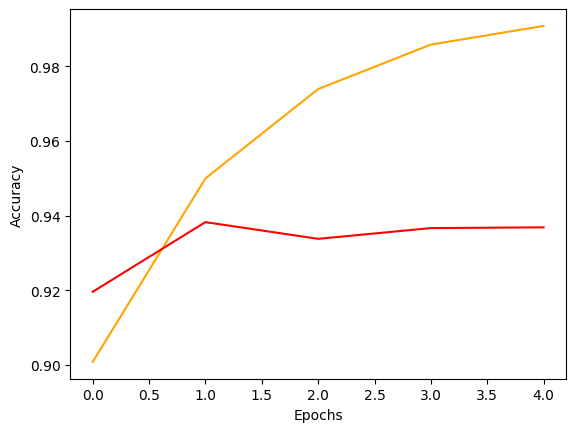

In [160]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

We achieved quite an impressive 94% test set accuracy, which is almost 10% higher than the performance of our bidirectional RNN-based architectures (LSTM, GRU). 

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> DEVLIN, Jacob, et al. Bert: Pre-training of deep bidirectional transformers for language understanding. In: *Proceedings of the 2019 conference of the North American chapter of the association for computational linguistics: human language technologies, volume 1 (long and short papers).* 2019. p. 4171-4186.

<a id="2">[2]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.

<a id="3">[3]</a> ZHU, Yukun, et al. Aligning books and movies: Towards story-like visual explanations by watching movies and reading books. In: *Proceedings of the IEEE international conference on computer vision.* 2015. p. 19-27.

<a id="4">[4]</a> MERITY, Stephen, et al. Pointer sentinel mixture models. *arXiv preprint arXiv:1609.07843*, 2016.

<a id="5">[5]</a> KINGMA, Diederik P.; BA, Jimmy. Adam: A method for stochastic optimization. *arXiv preprint arXiv:1412.6980,* 2014.

<a id="6">[6]</a> MAAS, Andrew, et al. Learning word vectors for sentiment analysis. In: *Proceedings of the 49th annual meeting of the association for computational linguistics: Human language technologies.* 2011. p. 142-150.